In [50]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
import pandas as pd
df = pd.read_csv(r'C:\Users\visha\OneDrive\Documents\Downloads\archive\insurance.csv')

In [52]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [53]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [13]:
df.shape

(1338, 7)

In [15]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [16]:
df.age

0       19
1       18
2       28
3       33
4       32
        ..
1333    50
1334    18
1335    18
1336    21
1337    61
Name: age, Length: 1338, dtype: int64

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [18]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [20]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [21]:
df.duplicated().sum()

np.int64(1)

In [22]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [26]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [30]:
df = df.drop_duplicates()

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges


In [33]:
df.shape

(1337, 7)

In [35]:
print(df["sex"].unique())
print(df["region"].unique())
print(df["smoker"].unique())

<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str


In [36]:
df["charges"].describe()

count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64

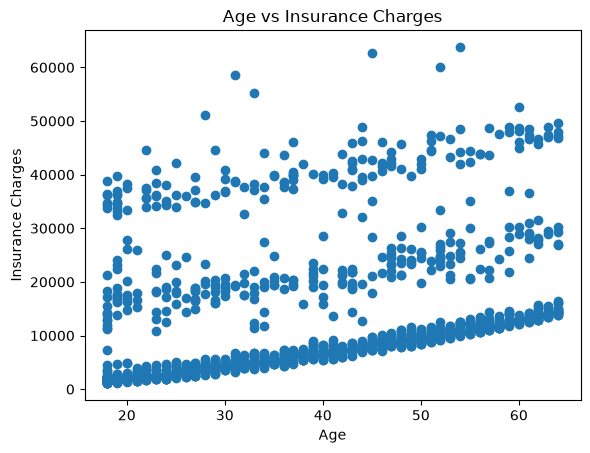

In [38]:
plt.scatter(df["age"], df["charges"])

plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Age vs Insurance Charges")

plt.show()

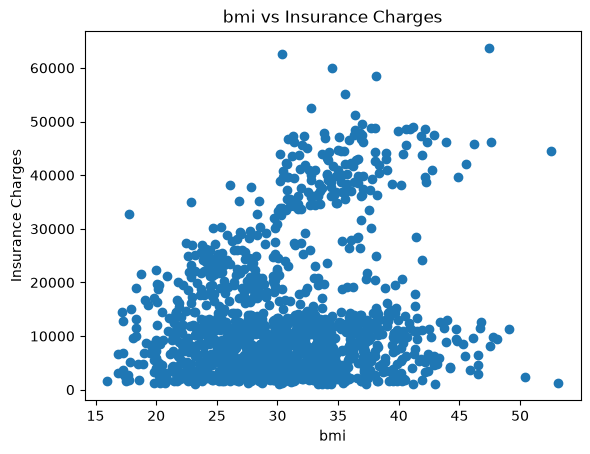

In [39]:
plt.scatter(df["bmi"], df["charges"])

plt.xlabel("bmi")
plt.ylabel("Insurance Charges")
plt.title("bmi vs Insurance Charges")

plt.show()

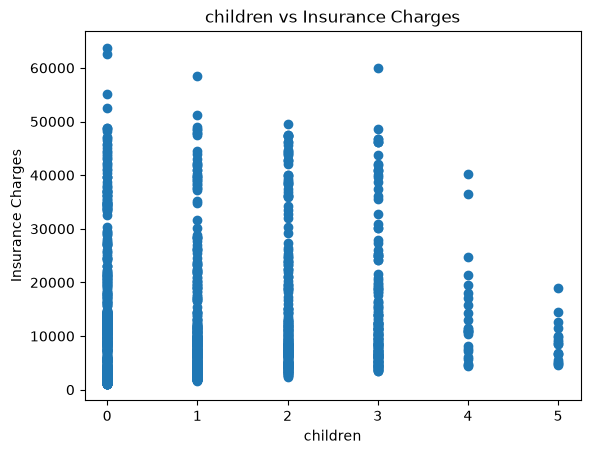

In [40]:
plt.scatter(df["children"], df["charges"])

plt.xlabel("children")
plt.ylabel("Insurance Charges")
plt.title("children vs Insurance Charges")

plt.show()

In [41]:
df.groupby("smoker")["charges"].mean()

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

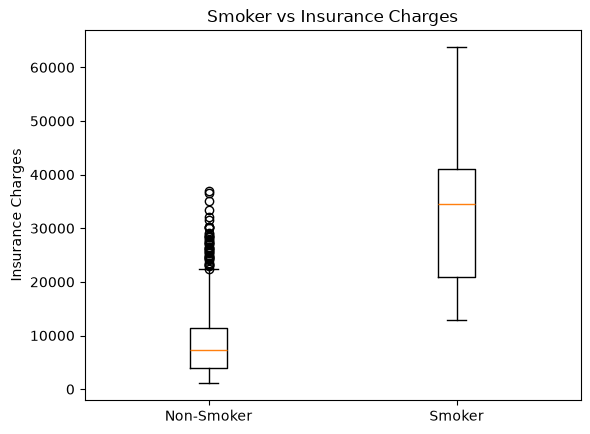

In [43]:
plt.boxplot(
    [df[df["smoker"] == "no"]["charges"],
     df[df["smoker"] == "yes"]["charges"]],
    tick_labels=["Non-Smoker", "Smoker"]
)

plt.ylabel("Insurance Charges")
plt.title("Smoker vs Insurance Charges")
plt.show()

In [44]:
df.groupby("smoker")["charges"].mean()

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

In [54]:
df = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)

In [55]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [56]:
x = df.drop("charges",axis=1)

In [57]:
y = df["charges"]

In [58]:
print(x.head())

   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0         0           1                 0   
1   18  33.770         1         1           0                 0   
2   28  33.000         3         1           0                 0   
3   33  22.705         0         1           0                 1   
4   32  28.880         0         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [59]:
print(y.head())

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [64]:
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (1338, 8)
y shape: (1338,)


In [65]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2, random_state=42
)

In [67]:
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (1070, 8)
x_test: (268, 8)
y_train: (1070,)
y_test: (268,)


In [68]:
from sklearn.linear_model import LinearRegression

In [69]:
model = LinearRegression()

In [70]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 256.98, 337.09, 425.28,...,-370.68,-657.86,-809.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.193e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [72]:
y_pred = model.predict(x_test)

In [73]:
print("Actual:", y_test.iloc[:5].values)
print("Predicted:", y_pred[:5])

Actual: [ 9095.06825  5272.1758  29330.98315  9301.89355 33750.2918 ]
Predicted: [ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656]


In [74]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.7835929767120723


In [75]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 4181.194473753654


In [78]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 33596915.85136146


In [79]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 5796.2846592762735


In [80]:
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4181.194473753654
MSE: 33596915.85136146
RMSE: 5796.2846592762735
R² Score: 0.7835929767120723


In [81]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -11931.219050326692
Coefficients: [ 2.56975706e+02  3.37092552e+02  4.25278784e+02 -1.85916916e+01
  2.36511289e+04 -3.70677326e+02 -6.57864297e+02 -8.09799354e+02]


In [82]:
new_person = pd.DataFrame({
    "age": [30],
    "bmi": [25.5],
    "children": [2],
    "sex_male": [1],
    "smoker_yes": [0],
    "region_northwest": [0],
    "region_southeast": [0],
    "region_southwest": [0]
})

In [83]:
prediction = model.predict(new_person)

print("Predicted Insurance Charges:", prediction[0])

Predicted Insurance Charges: 5205.878074710587


In [86]:
sample = x_test.iloc[[0]]

actual = y_test.iloc[0]
predicted = model.predict(sample)[0]

print("Actual Charges:", actual)
print("Predicted Charges:", predicted)

Actual Charges: 9095.06825
Predicted Charges: 8969.550274436167


In [87]:
error_percent = abs(actual - predicted) / actual * 100

print("Error %:", error_percent)

Error %: 1.3800663405008842


In [88]:
error = abs(actual - predicted)
print(error)

125.5179755638328


In [89]:
accuracy_percent = r2 * 100

print("Model Performance:", accuracy_percent, "%")

Model Performance: 78.35929767120723 %


In [90]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4181.194473753654
RMSE: 5796.2846592762735
R² Score: 0.7835929767120723


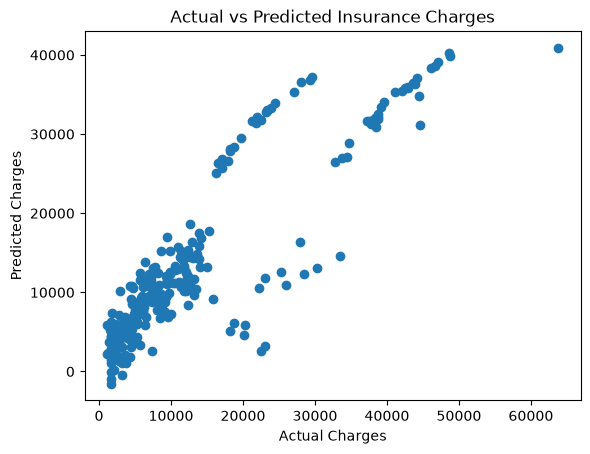

In [91]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()